In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/Telco_customer_churn.csv")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
df.drop(['CustomerID', 'Count', 'Country', 'State'], axis=1, inplace=True)

In [7]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.dropna(inplace=True)

In [11]:
print(df.columns.tolist())

['City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [12]:
df['Churn'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [20]:
import pandas as pd
import numpy as np
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("../data/raw/Telco_customer_churn.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Drop unnecessary columns
drop_cols = [
    'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Score', 'CLTV', 'Churn Reason'
]

df.drop(columns=drop_cols, inplace=True)

# Convert Total Charges
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

# 🔥 Select only important features (for simple UI)
features = ['Tenure Months', 'Monthly Charges', 'Total Charges']

X = df[features]
y = df['Churn Value']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model (better than logistic)
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

# Save model
os.makedirs("app/model", exist_ok=True)
pickle.dump(model, open("app/model/churn_model.pkl", "wb"))

print("✅ Model trained & saved successfully!")

Accuracy: 0.759772565742715
✅ Model trained & saved successfully!


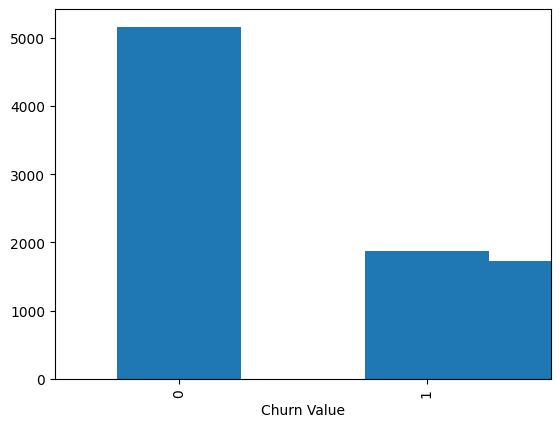

In [22]:
import matplotlib.pyplot as plt

df['Tenure Months'].hist()
plt.savefig("../app/static/images/chart1.png")

df['Monthly Charges'].hist()
plt.savefig("../app/static/images/chart2.png")

df['Churn Value'].value_counts().plot(kind='bar')
plt.savefig("../app/static/images/chart3.png")

In [23]:
import matplotlib.pyplot as plt

# Chart 1
df['Tenure Months'].hist()
plt.title("Tenure Distribution")
plt.savefig("../app/static/images/chart1.png")
plt.clf()

# Chart 2
df['Monthly Charges'].hist()
plt.title("Monthly Charges Distribution")
plt.savefig("../app/static/images/chart2.png")
plt.clf()

# Chart 3
df['Churn Value'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.savefig("../app/static/images/chart3.png")
plt.clf()

<Figure size 640x480 with 0 Axes>